# Inverse designed grating coupler

Updating... check back later.

## Config

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import luminescent as lm

path = os.path.join("runs", "GC")

theta = 10 * np.pi / 180
wavelength = 1.55
bandwidth = 0.005
nwls = 3
wavelengths = np.linspace(wavelength - bandwidth / 2, wavelength + bandwidth / 2, nwls)

# simulation parameters
nres = 6
dtype = "f32"
boundaries = ["PML", ["PEC", "PML"], "PML"]
PML_decay = [0.01, 0.1, 0.01]
relative_courant = 0.95
frame_every = 5

# horizontal dimensions
r = 4
R = 1.8 * r
w_design = 2 * R
l_design = 1.5 * w_design
w_wg = 0.5
l_wg = 3
taper = 0

margin = 1

# vertical dimensions
h_wg = 0.22
h_slab = 0.15
h_rib = 0.07


zmargin = .8
port_offset = 0.4
source_offset = 0.4
z_port = h_wg + port_offset

zmin = -zmargin
zmax = h_wg + port_offset + source_offset

# materials
material_core = "Si"
material_clad = "SiO2"
materials = {
    "Si": lm.Material(3.45),
    "SiO2": lm.Material(1.44),
}

n_core = materials[material_core]["n"]
n_clad = materials[material_clad]["n"]
lambda_core = wavelength / n_core
lambda_clad = wavelength / n_clad
dx = lambda_core / nres

background = material_clad
materials["design"] = lm.PlaceholderMaterial(n_core)

# layer stack. lower mesh order layers override higher mesh order layers.
WG = (1, 0)
SLAB = (2, 0)
RIB = (3, 0)
CLAD = (4, 0)
DESIGN = (1001, 0)

zmin_design = h_slab
h_design = h_rib

layers = {
    "core": LayerLevel(
        layer=LogicalLayer(layer=WG),
        zmin=0,
        thickness=h_wg,
        material=material_core,
        mesh_order=200,
    ),
    "slab": LayerLevel(
        layer=LogicalLayer(layer=SLAB),
        zmin=0,
        thickness=h_slab,
        material=material_core,
        mesh_order=100,
    ),
    "design": LayerLevel(
        layer=LogicalLayer(layer=DESIGN),
        zmin=zmin_design,
        thickness=h_design,
        material="design",
        mesh_order=1,
    ),
}
layer_stack = LayerStack(layers=layers)

# mirrors = ["y-"]
views = [
    lm.View("Ey", y=0, z=zmin_design + h_design / 2),
    # lm.View("Ey", z=zmin_design + h_design / 2),
]

## Geometry

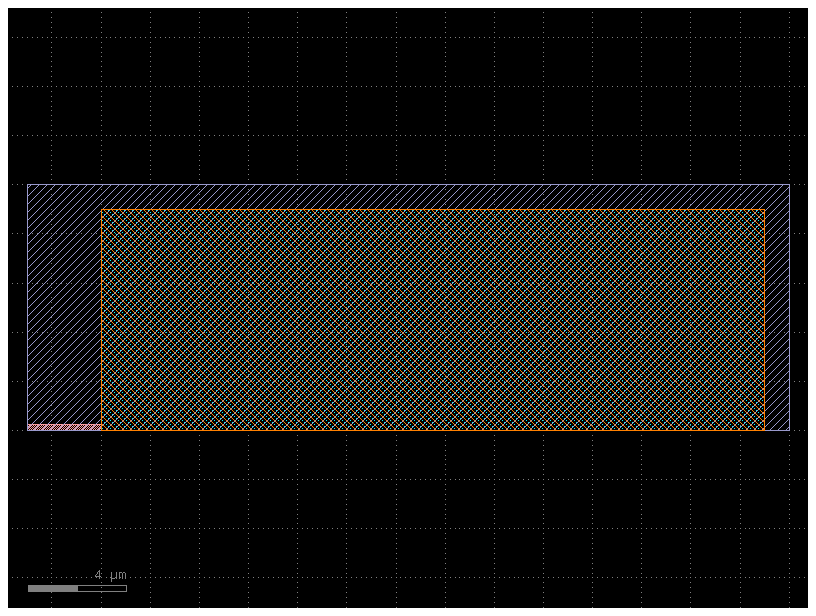

In [10]:
# Build the gdsfactory component to be optimized.
c = gf.Component()
d = c << lm.mimo(
    l_design,
    w_design / 2,
    west=[w_wg / 4],
    w_wg=w_wg / 2,
    l_wg=l_wg,
    layer_wg=WG,
    layer_design=(DESIGN,),
    layer_fill=SLAB,
    taper=[(taper / 2, 0)],
)

ox_design = -l_design + R
d.movex(ox_design)

c << gf.components.bbox(component=c, layer=CLAD, top=margin, right=margin)

c.add_port("o1", port=d.ports["o1"])

frames = [
    lm.Frame(
        "wg",
        start=[-w_wg / 4 - margin, zmin],
        stop=[w_wg / 4, zmax],
        boundaries=[("PML", "PEC"), "PML"],
        mode_solver_wavelengths=[wavelength],
    ),
    lm.Frame(
        "beam",
        modes=[
            [
                lm.gaussian_mode(
                    r,
                    R,
                    Z=1 / n_clad,
                    dx=dx,
                    theta=theta,
                    wavelength=wavelength,
                    half="y+",
                )
            ]
        ],
        start=[-R, 0],
        stop=[R, R],
    ),
]

origin = [
    np.sin(theta) * (source_offset + port_offset),
    0,
    h_wg + port_offset + source_offset,
]
basis = [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
sources = [
    lm.Source(
        "o2",
        origin,
        basis,
        wavelength=wavelength,
        bandwidth=wavelength / 5,
        frame="beam",
    )
]

origin = [np.sin(theta) * (port_offset), 0, h_wg + port_offset]
monitors = [
    lm.Monitor("o1", *lm.from_gf_port(c, "o1"), frame="wg"),
    lm.Monitor("o2", origin, basis, frame="beam"),
]

tmax = (
    1.5
    * (
        (port_offset + source_offset) / np.cos(theta) * n_clad
        + (l_design + w_design / 2 + l_wg) * n_core
    )
    / wavelength
    + sources[0]["duration"]
)

bbox = c.bbox_np().tolist()
bbox[0].append(zmin)
bbox[1].append(zmax)

c.plot()

In [ ]:
optimizer = lm.Optimizer(
    stoploss=0.2,
    lowloss=0.6,
    iters=10,
    contrast=0,
    momentum=0.7,
)
targets = [
    lm.Target(src="o2@0-", dst="o1@0+", target=1, weight=1 / nwls, wavelength=wl)
    for wl in wavelengths
]
designs = [
    lm.Design(
        name="design",
lmin = 0.1
        layer=DESIGN,
        fill_material=material_core,
        void_material=material_clad,
        component=c,
        layer_stack=layer_stack,
        materials=materials,
        repdims=[3],
        anchordims=[],
    )
]

## Solve

origin: [-21.0, 0.125, 0.0], basis: [[-1.2246467991473532e-16, -1.0, 0], [0, 0, 1], [-1.0, 1.2246467991473532e-16, 0]], start: [-1.125, -1], stop: [0.125, 1.22],
polyeps: [(<POLYGON ((0.125 0, -0.125 0, -0.125 0, -0.125 5e-5, -0.125 7.333e-5, -0.125...>, 11.902500000000002, 'core'), (<POLYGON ((0.125 -1, 0.125 1.22, -1.125 1.22, -1.125 -1, 0.125 -1))>, 2.0736, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 00A0


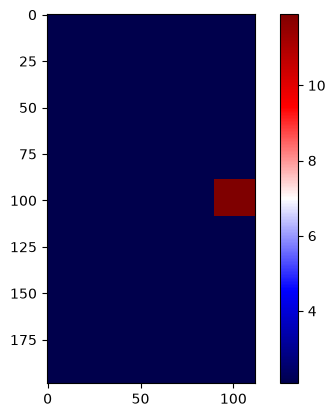

wg/1.55 mode 0 (neff=2.406+0.000j)
saving mode to /home/weihu/moon/luminescent/runs/GC/modes/wg/1.55/0.npz
using simulation folder /home/weihu/moon/luminescent/runs/GC


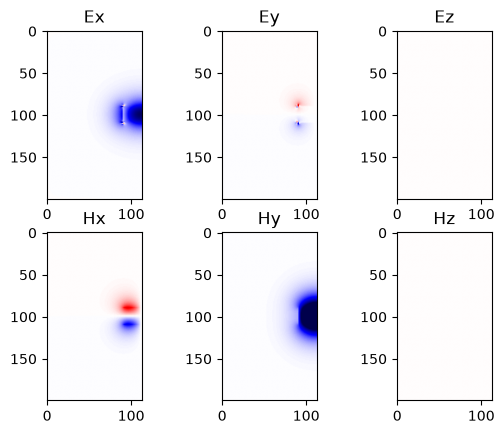

In [12]:
kwargs = dict(
    path=path,
    wavelength=wavelength,
    wavelengths=wavelengths,
    frames=frames,
    monitors=monitors,
    sources=sources,
    boundaries=boundaries,
    bbox=bbox,
    materials=materials,
    background=background,
    nres=nres,
    tmax=tmax,
    PML_decay=PML_decay,
    relative_courant=relative_courant,
    dtype=dtype,
    frame_every=frame_every,
    views=views,
    designs=designs,
    targets=targets,
    optimizer=optimizer,
    # load_designs=['design']
)

lm.mesh(path, c, layer_stack, materials, zmin, zmax)
lm.setup(**kwargs)

## Movie


Video generated successfully at /home/weihu/moon/luminescent/runs/GC/Ey_None_0_0.185.gif!


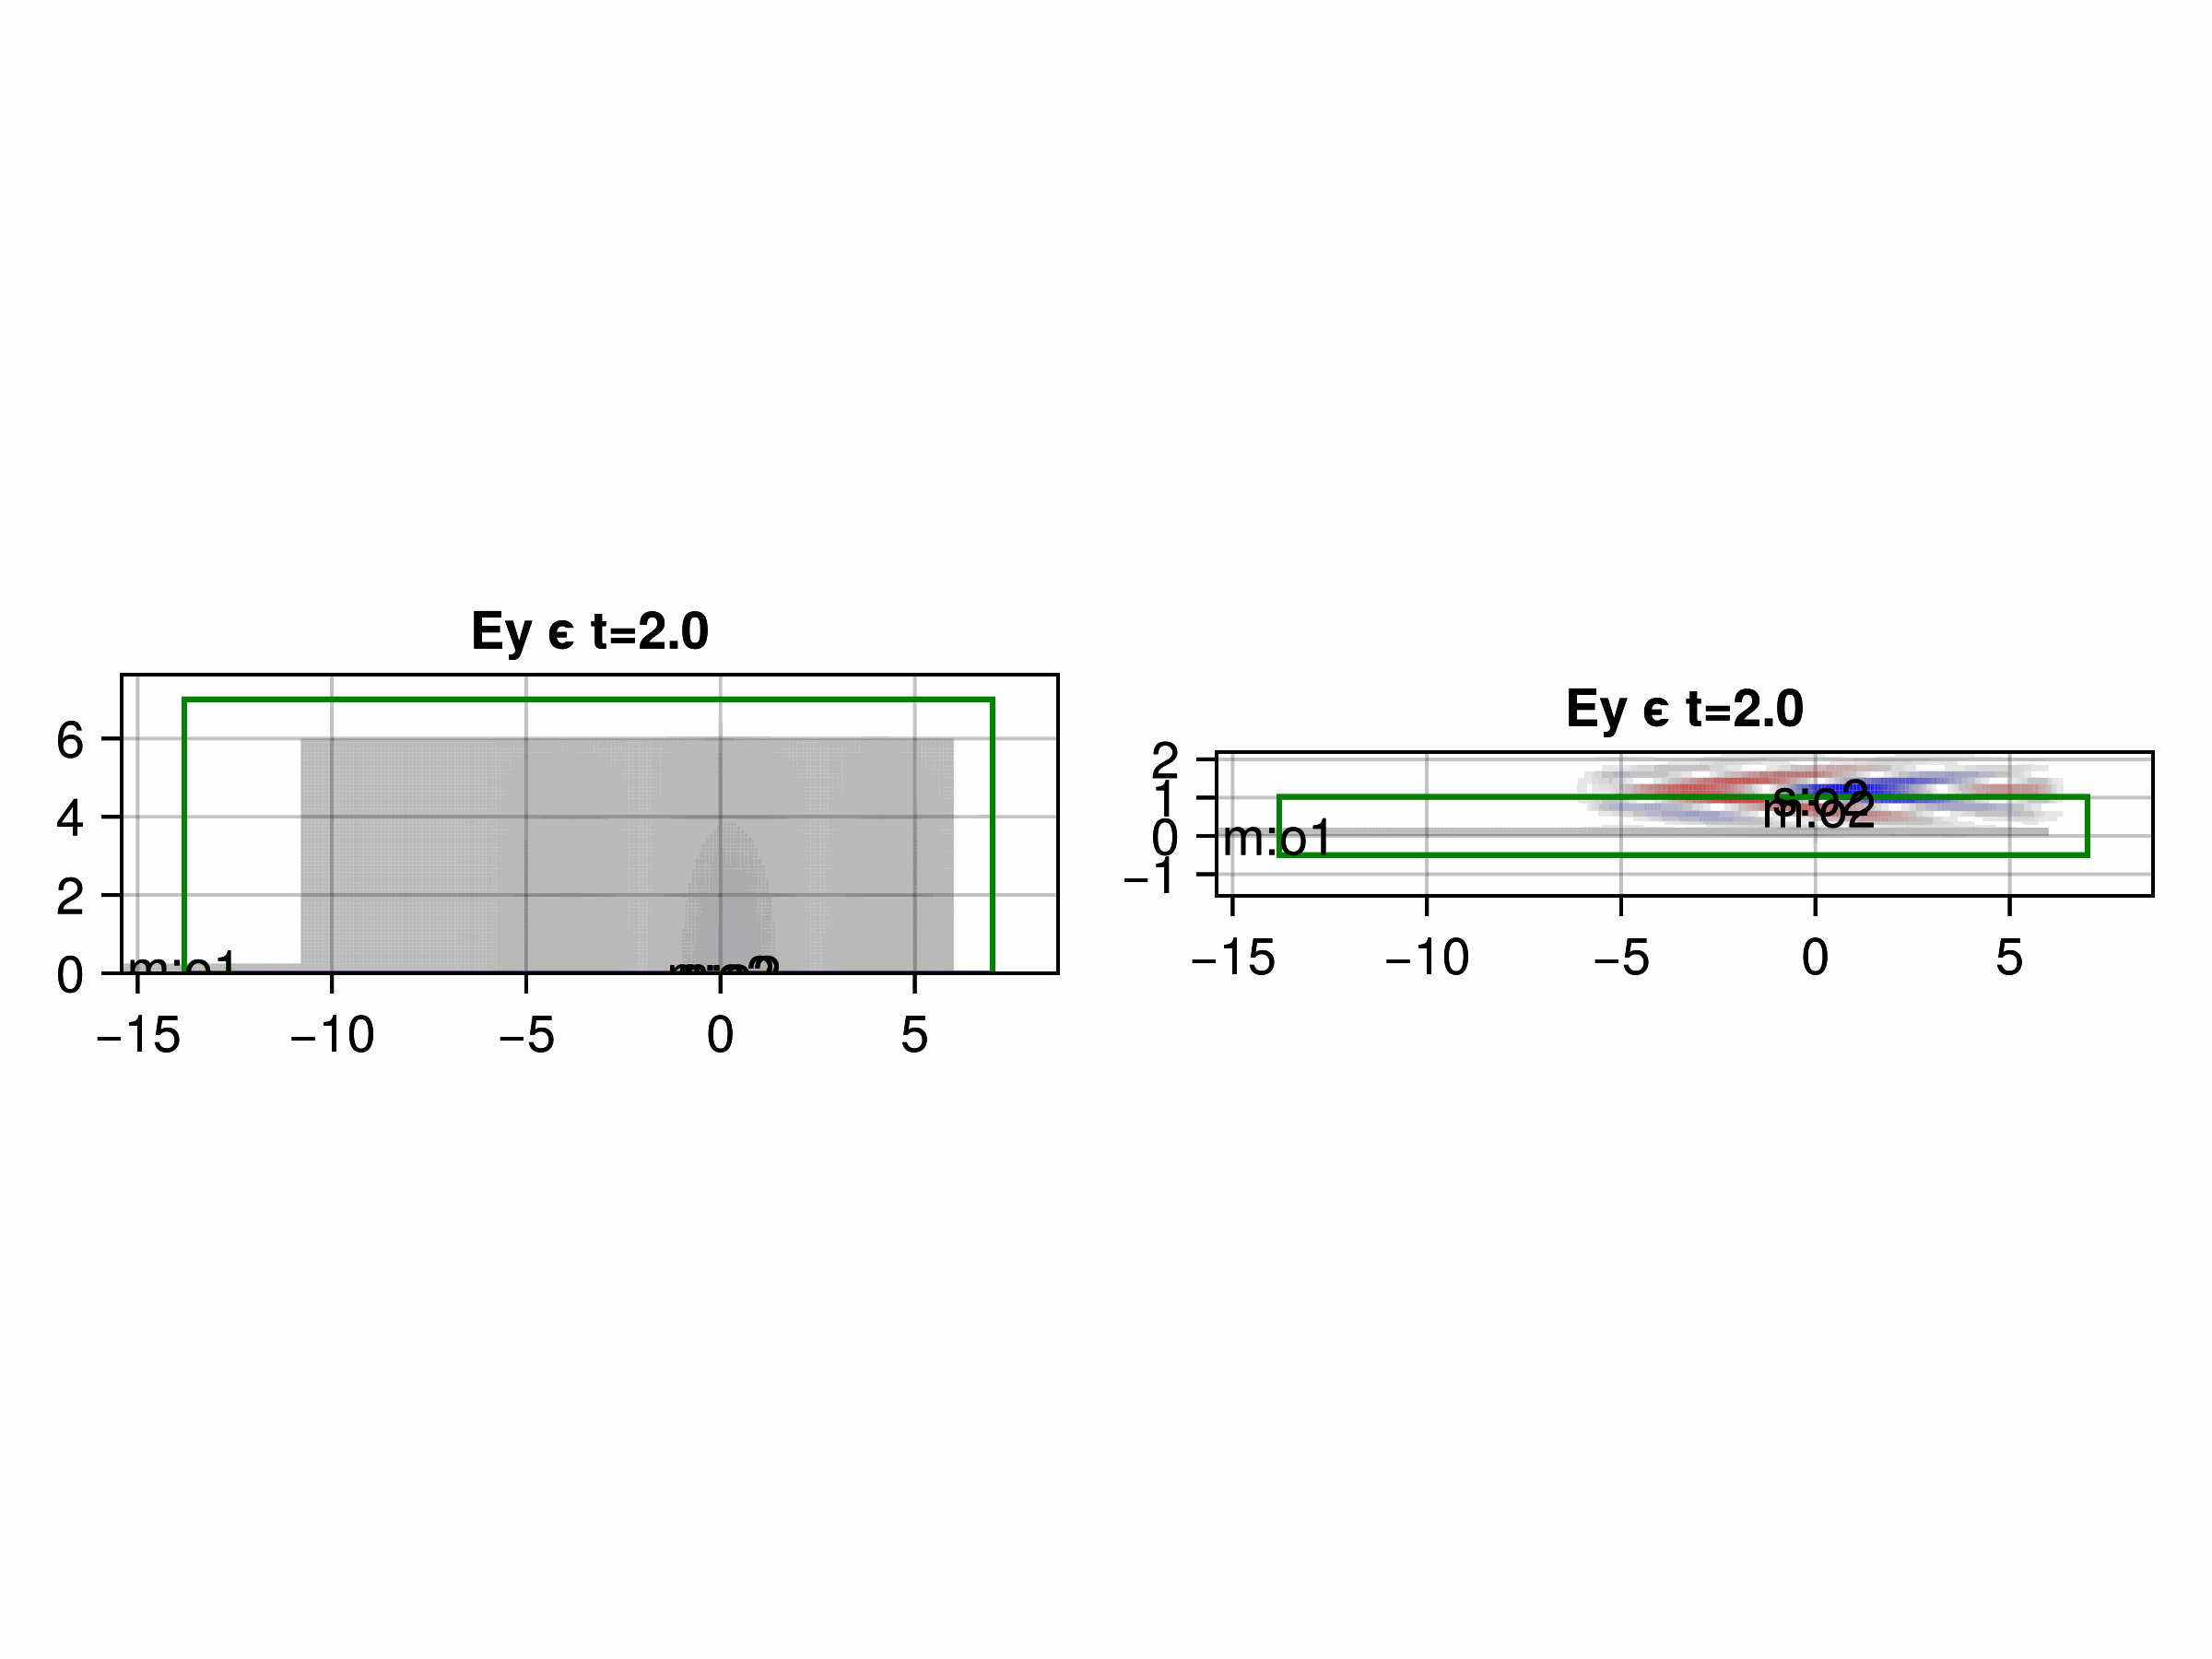

In [13]:
lm.movie(path)

In [14]:
sol = lm.load(path)
o2 = sol["monitors"]["o2_mode"]
o1 = sol["monitors"]["o1_mode"]

# + denotes forward propagating mode (wrt port monitor normal)
S21 = o2["modes"][0]["+"] / o1["modes"][0]["-"]
S11 = o1["modes"][0]["+"] / o1["modes"][0]["-"]

plt.figure()
plt.plot(wavelengths, np.abs(S21) ** 2, label="S21 power")
plt.plot(wavelengths, np.abs(S11) ** 2, label="S11 power")
plt.xlabel("wavelength [um]")
plt.ylabel("power")
plt.ylim(0, 1)
plt.legend()
plt.show()


loading solution from /home/weihu/moon/luminescent/runs/GC
may take a minute if simulation folder is remotely mounted


FileNotFoundError: [Errno 2] No such file or directory: '/home/weihu/moon/luminescent/runs/GC/.solution.json.tar'